<a href="https://colab.research.google.com/github/AtharvaChitnis/PGIT/blob/main/Data_Scienc3e.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Convert Text Delimited CSV to Hours format

# Convert a Time Column into Hours Format (HH:MM::SS or Decimal)

In [ ]:
import pandas as pd

In [ ]:
df1 =pd.read_csv("/Text Delimited CSV - Sheet1 (1).csv")

In [ ]:
print(df1)

   id      name  Duration
0    1  Atharva     08:00
1    2   Vikas   09:00:02
2    3  Chitnis  24:00:00


In [ ]:
df1["hours"] = pd.to_timedelta(df1["duration"],errors='coerce').dt.total_seconds() / 3600

In [ ]:
print(df1)

   id      name  duration      hours
0    1  Atharva     08:12        NaN
1    2   Vikas   09:00:02   9.000556
2    3  Chitnis  24:00:00  24.000000


Convert a Time Column into Hours Format (HH:MM::SS or Decimal)

In [ ]:
import pandas as pd


In [ ]:
df = pd.read_csv("/Text Delimited CSV - Sheet1 (1).csv")

In [ ]:
df["hours"] = pd.to_timedelta(df["duration"],errors='coerce').dt.total_seconds() / 3600

In [ ]:
print(df)

   id      name  duration      hours
0    1  Atharva     08:12        NaN
1    2   Vikas   09:00:02   9.000556
2    3  Chitnis  24:00:00  24.000000


# Bucketing/Datat Binning

In [ ]:
import pandas as pd

# Sample dataset with ages
data = {'Name': ['Atharva', 'Vikas', 'Chitnis', 'Marshall', 'VOX', 'FENDER'],
        'Age': ['12', '50', '7500', '125', '70', '300']}

df = pd.DataFrame(data)

# Convert 'Age' column to numeric
df['Age'] = pd.to_numeric(df['Age'])

# Define bin edges and labels
bins = [0, 10, 50, 100, 150, 200, 250, 500, 1000]  # bin edges
# Added more labels to match the number of bins (bins - 1)
labels = ['Child', 'Teenager', 'Adult', 'Senior', 'Super Senior', 'Elder', 'Ancient', 'Immortal']  # Bin labels

# Apply binning
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

# Display the result
print(df)

       Name   Age Age_Group
0   Atharva    12  Teenager
1     Vikas    50  Teenager
2   Chitnis  7500       NaN
3  Marshall   125    Senior
4       VOX    70     Adult
5    FENDER   300   Ancient


In [ ]:
df['Age Bin'] = pd.cut(df['Age'], bins=5) #5 equual-width bins
print(df)

       Name   Age Age_Group           Age Bin
0   Atharva    12  Teenager   (4.512, 1509.6]
1     Vikas    50  Teenager   (4.512, 1509.6]
2   Chitnis  7500       NaN  (6002.4, 7500.0]
3  Marshall   125    Senior   (4.512, 1509.6]
4       VOX    70     Adult   (4.512, 1509.6]
5    FENDER   300   Ancient   (4.512, 1509.6]


# Averaging Data

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
#Python code for averaging data
#Method 1: Using Basic Arithmetic
#Sample Data

data = [10,20,30,40,50]

#Compute average
average = sum(data)/len(data)

print('Average', average)

Average 30.0


In [ ]:
#MEthod 2: Using statistics.mean()
import statistics
#Sample Data

data = [80,520,255,46,47,9784201]

#Compute average using statistics module
average = statistics.mean(data)

print("Average:", average)

Average: 1630858.1666666667


# Build Acyclic Graph

The graph is a valid DAG.


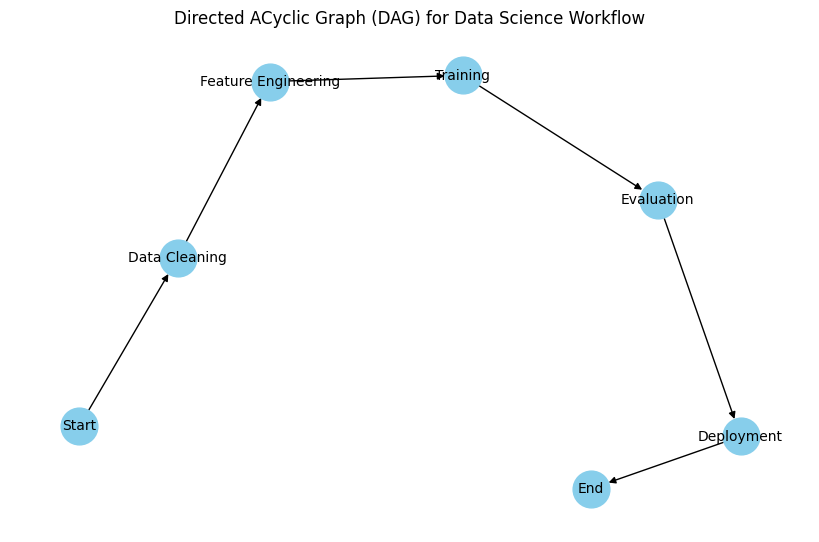

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

#Create a Directed Graph(DAG)
DAG = nx.DiGraph()

#Add edges (NO CYCLES ALLOWED)

edges = [
    ('Start', 'Data Cleaning'),
    ('Data Cleaning', 'Feature Engineering'),
    ('Feature Engineering', 'Training'),
    ('Training', 'Evaluation'),
    ('Evaluation', 'Deployment'),
    ('Deployment', 'End')
]

DAG.add_edges_from(edges)

# Check if the graph is acyclic

if nx.is_directed_acyclic_graph(DAG):
  print("The graph is a valid DAG.")
else:
  print("The graph contains cycles")

#Draw the DAG
plt.figure(figsize=(8,5))
pos = nx.spring_layout(DAG) #Layout for better visuallization
nx.draw(DAG, pos, with_labels=True, arrows=True, node_size=700, node_color='skyblue', font_size=10)
plt.title("Directed ACyclic Graph (DAG) for Data Science Workflow")
plt.show()


# K-Means Clustering

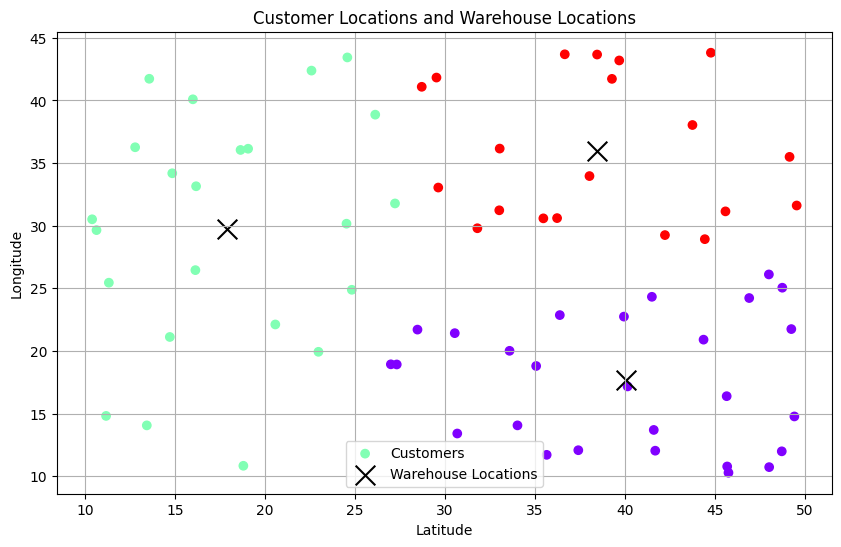

Warehouse Location 1: Latitude 40.06, Longitude 17.66
Warehouse Location 2: Latitude 17.87, Longitude 29.74
Warehouse Location 3: Latitude 38.45, Longitude 35.94


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from google.colab import files

# Step 1: Load or Simulate Customer Location data
# Simulated data (Customer location: latitude, longitude)
num_customers = 70  # Define a consistent number of customers

data = {
    "Customer_ID": range(1, num_customers + 1),
    'Latitude': np.random.uniform(10, 50, num_customers),
    'Longitude': np.random.uniform(10, 44, num_customers)
}

df = pd.DataFrame(data)

# Step 2: Apply K-Means Clustering (Choose 3 Clusters for warehouse locations)
k = 3
kmeans = KMeans(n_clusters=k, random_state=42)
df['Cluster'] = kmeans.fit_predict(df[['Latitude', 'Longitude']])

# Step 3: Get Cluster Centers (Warehouse Locations)
warehouse_locations = kmeans.cluster_centers_

# Step 4: Visualizations
plt.figure(figsize=(10, 6))
plt.scatter(df['Latitude'], df['Longitude'], c=df['Cluster'], cmap='rainbow', label='Customers')
plt.scatter(warehouse_locations[:, 0], warehouse_locations[:, 1], c='black', marker='x', s=200, label='Warehouse Locations')

plt.xlabel('Latitude')
plt.ylabel('Longitude')
plt.title('Customer Locations and Warehouse Locations')
plt.legend()
plt.grid(True)
plt.show()

# Step 5: Print Suggested Warehouse Locations
for i, location in enumerate(warehouse_locations):
    print(f"Warehouse Location {i + 1}: Latitude {location[0]:.2f}, Longitude {location[1]:.2f}")